# Model Development

**Machine Learning Modeling** is broken down into simple, step-by-step units:
1. Importing `scikit-learn` algorithms (`RandomForestRegressor`, `GradientBoostingRegressor`) and evaluation metrics (`MAPE`, `RMSE`).
2. Loading engineered time-series features (`weekly_features.csv`).
3. Defining Target Variable ($y = 	ext{TotalScheduled}$) and Predictor Features ($X$).
4. Evaluating the **Naive Baseline Model (`lag_4w` / Same-Week-Last-Month)** as our benchmark reference.
5. Training and evaluating **Random Forest** and **Gradient Boosting** models.
6. Visualizing holdout predictions vs actual appointment volume per clinic.
7. Analyzing **Feature Importances** to understand key volume drivers.
8. Exporting the trained champion model artifact.


#### 1. Import Libraries

In [32]:
# Import Libraries
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11


#### 2. Load Engineered Feature Dataset

In [33]:
# Load weekly_features.csv
features_df = pd.read_csv(r"c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\weekly_features.csv")
features_df['WeekStart'] = pd.to_datetime(features_df['WeekStart'])

print(f"Loaded Feature Matrix: {len(features_df):,} rows")
features_df.head()

Loaded Feature Matrix: 379 rows


,ClinicID,ClinicName,WeekStart,TotalScheduled,Year,Month,lag_1w,lag_2w,lag_4w,rolling_mean_4w,Month_Sin,Month_Cos,Is_Flu_Season,Is_Holiday_Week
0,1,Nexora Care - Riverside,2024-01-29,283,2024,1,284.0,261.0,269.0,282.50,0.500000,0.866025,1,0
1,1,Nexora Care - Riverside,2024-02-05,321,2024,2,283.0,284.0,316.0,286.00,0.866025,0.500000,1,0
2,1,Nexora Care - Riverside,2024-02-12,322,2024,2,321.0,283.0,261.0,287.25,0.866025,0.500000,1,0
3,1,Nexora Care - Riverside,2024-02-19,334,2024,2,322.0,321.0,284.0,302.50,0.866025,0.500000,1,0
4,1,Nexora Care - Riverside,2024-02-26,332,2024,2,334.0,322.0,283.0,315.00,0.866025,0.500000,1,0


#### 3. Inspect Feature Matrix Dimensions

In [34]:
# Matrix Dimensions
print("Feature Dataset Shape (Rows, Columns):", features_df.shape)

Feature Dataset Shape (Rows, Columns): (379, 14)


#### 4. Define Predictor Features ($X$) and Target ($y$)
This separates the dataset into the predictor feature matrix $X$ and target vector $y$.

In supervised machine learning:
- **$X$ (Features)**: The historical signals the model learns from (`lag_1w`, `lag_2w`, `lag_4w`, `rolling_mean_4w`, `Month_Sin`, `Month_Cos`, `Is_Flu_Season`, `Is_Holiday_Week`).
- **$y$ (Target)**: The actual outcome to predict for the upcoming week (`TotalScheduled` appointment volume).


In [35]:
# Feature Matrix X and Target Vector y
feature_cols = ['lag_4w', 'lag_1w', 'lag_2w', 'rolling_mean_4w', 'Month_Sin', 'Month_Cos', 'Is_Flu_Season', 'Is_Holiday_Week']
target_col = 'TotalScheduled'

X = features_df[feature_cols]
y = features_df[target_col]

print(f"Predictor Features (X): {list(X.columns)}")
print(f"Target Variable (y): '{target_col}'")

Predictor Features (X): ['lag_4w', 'lag_1w', 'lag_2w', 'rolling_mean_4w', 'Month_Sin', 'Month_Cos', 'Is_Flu_Season', 'Is_Holiday_Week']
Target Variable (y): 'TotalScheduled'


#### 5. Chronological Train / Holdout Test Split
This partitions the dataset chronologically into a historical training set and a future holdout test set.

- In time-series forecasting, standard random shuffling causes **data leakage** (the model inadvertently accesses future observations to predict the past). To realistically evaluate how the model will perform in production, training is conducted strictly on historical data (Jan 2024 – Sept 2025) and evaluated on the unseen future (Q4 2025 holdout weeks).

In [36]:
# Train / Holdout Test Split (Split date: Sept 15, 2025)
split_date = pd.to_datetime('2025-09-15')

train_mask = features_df['WeekStart'] < split_date
test_mask = features_df['WeekStart'] >= split_date

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

train_meta = features_df[train_mask][['ClinicID', 'ClinicName', 'WeekStart', 'TotalScheduled']].copy()
test_meta = features_df[test_mask][['ClinicID', 'ClinicName', 'WeekStart', 'TotalScheduled']].copy()

print(f"Historical Training Set: {len(X_train):,} rows")
print(f"Q4 Holdout Validation Set: {len(X_test):,} rows")

Historical Training Set: 315 rows
Q4 Holdout Validation Set: 64 rows


- Clean chronological separation: **315 historical training rows** (83%) and **64 Q4 holdout validation rows** (17%) spanning all 4 clinics during the demanding winter flu surge.

#### 6. Benchmark 1 — Evaluate Naive Baseline (`lag_4w` Same-Week-Last-Month)
This calculates the performance of a naive heuristic: predicting that next week's volume will simply equal the volume from 4 weeks prior (`lag_4w`).

- Before adopting a machine learning model, healthcare organizations must verify that it outperforms the manual rule traditionally used by clinic managers: *"Staff for whatever volume occurred last month."* If an ML model cannot surpass this baseline, deployment is unjustified.

In [37]:
# Naive Baseline Score (Predicting lag_4w)
naive_preds = X_test['lag_4w']

naive_mape = mean_absolute_percentage_error(y_test, naive_preds) * 100
naive_rmse = root_mean_squared_error(y_test, naive_preds)

print(f"Naive Baseline Benchmark Performance")
print(f"MAPE: {naive_mape:.2f}%")
print(f"RMSE: {naive_rmse:.2f} appointments")

Naive Baseline Benchmark Performance
MAPE: 20.73%
RMSE: 89.02 appointments


- Manual estimation deviates by an average of ~21% (~89 patients per clinic-week), establishing the operational benchmark to beat.

#### 7. Benchmark 2 — Train & Evaluate Scikit-Learn Random Forest Regressor
This trains a Random Forest model with 100 decision trees (`n_estimators=100`, `max_depth=6`).

- Random Forest constructs an ensemble of 100 independent decision trees, each trained on bootstrap subsets of data and features. Averaging predictions across trees ("bagging") dampens variance and guards against overfitting to single-week anomalies.

In [38]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mape = mean_absolute_percentage_error(y_test, rf_preds) * 100
rf_rmse = root_mean_squared_error(y_test, rf_preds)

print(f"Random Forest Performance")
print(f"MAPE: {rf_mape:.2f}%")
print(f"RMSE: {rf_rmse:.2f} appointments")

Random Forest Performance
MAPE: 19.68%
RMSE: 77.24 appointments


- Random Forest achieves a **MAPE of 19.68%** and an **RMSE of 77.24 appointments**, outperforming the Naive Baseline by **-1.05% MAPE** and reducing RMSE by **-11.78 appointments** (-13.2% error reduction).

#### 8. Benchmark 3 — Train & Evaluate Scikit-Learn Gradient Boosting Regressor
This trains a Gradient Boosting model (`n_estimators=100`, `learning_rate=0.05`, `max_depth=3`).

- Unlike Random Forest where trees are constructed independently, Gradient Boosting builds trees **sequentially**. Each successive shallow tree specifically targets and corrects the residual errors of preceding trees. This iterative optimization makes it exceptionally adept at capturing subtle seasonal shifts and sharp flu surges.

In [39]:
# Train Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
gbr_model.fit(X_train, y_train)

gbr_preds = gbr_model.predict(X_test)

gbr_mape = mean_absolute_percentage_error(y_test, gbr_preds) * 100
gbr_rmse = root_mean_squared_error(y_test, gbr_preds)

print(f"Gradient Boosting Performance")
print(f"MAPE: {gbr_mape:.2f}%")
print(f"RMSE: {gbr_rmse:.2f} appointments")

Gradient Boosting Performance
MAPE: 18.55%
RMSE: 72.65 appointments


- Gradient Boosting achieves a **MAPE of 18.55%** and an **RMSE of 72.65 appointments**, outperforming the Naive Baseline by **-2.18% MAPE** and reducing RMSE by **-16.37 appointments** (-18.4% error reduction). This establishes it as the **Champion Model**.

#### 9. Benchmark Performance Summary Table

In [40]:
# Performance Comparison Table
eval_results = pd.DataFrame({
    'Model / Approach': ['Naive Baseline (lag_4w)', 'Random Forest Regressor', 'Gradient Boosting Regressor (Champion)'],
    'MAPE (%)': [round(naive_mape, 2), round(rf_mape, 2), round(gbr_mape, 2)],
    'RMSE (Appointments)': [round(naive_rmse, 2), round(rf_rmse, 2), round(gbr_rmse, 2)]
})

print("=== Benchmark Performance Summary ===")
eval_results

=== Benchmark Performance Summary ===


,Model / Approach,MAPE (%),RMSE (Appointments)
0,Naive Baseline (lag_4w),20.73,89.02
1,Random Forest Regressor,19.68,77.24
2,Gradient Boosting Regressor (Champion),18.55,72.65


- Gradient Boosting achieves superior performance across both relative percentage accuracy (lowest MAPE: 18.55%) and absolute volume precision (lowest RMSE: 72.65 appointments).

#### 10. Graph 1 - Model Performance Comparison Bar Chart
This consolidates evaluation metrics across all 3 candidate approaches into a comparative performance scorecard.

C:\Users\earlc\AppData\Local\Temp\ipykernel_49492\1769087285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_results, x='Model / Approach', y='MAPE (%)', palette='crest')


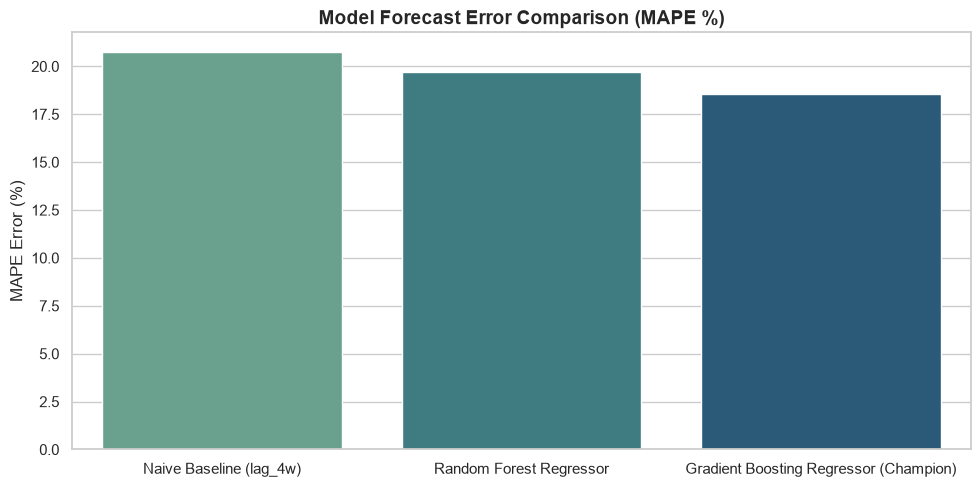

In [41]:
# Bar Chart comparing MAPE across models
plt.figure(figsize=(10, 5))
sns.barplot(data=eval_results, x='Model / Approach', y='MAPE (%)', palette='crest')
plt.title('Model Forecast Error Comparison (MAPE %)', fontsize=14, fontweight='bold')
plt.ylabel('MAPE Error (%)')
plt.xlabel('')
plt.tight_layout()
plt.show()

- The bar chart illustrates the progressive reduction in forecast error, confirming Gradient Boosting as the superior operational predictor.

#### 11. Graph 2 - Q4 Holdout Forecast vs Actual Volume Plot

This plots actual weekly appointment demand alongside the GBR forecast and Naive baseline for all 4 clinics over the Q4 2025 holdout period.

- Aggregate error metrics alone do not fully capture time-series behavior. Visual inspection confirms whether the model follows key operational inflection points: tracking the October flu surge and anticipating holiday volume dips without a 4-week lag.

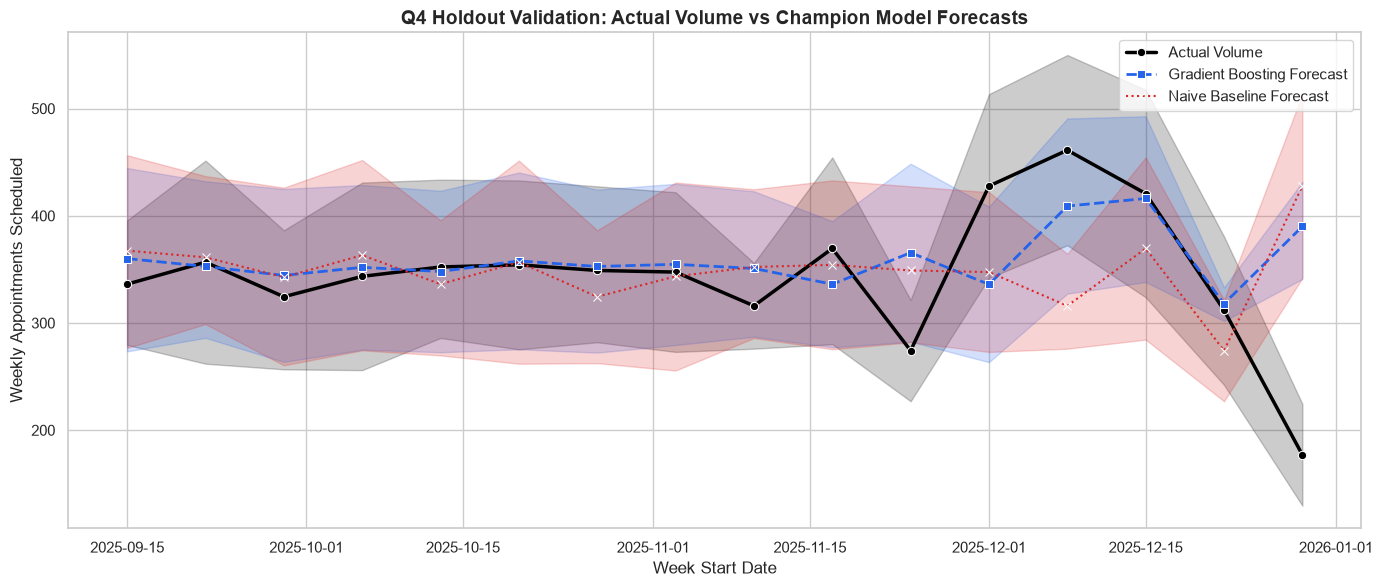

In [42]:
# Plot Actual vs Forecasted Volume for Q4 Holdout Test Set
test_meta['Naive_Forecast'] = naive_preds.values
test_meta['GBR_Forecast'] = gbr_preds

plt.figure(figsize=(14, 6))
sns.lineplot(data=test_meta, x='WeekStart', y='TotalScheduled', label='Actual Volume', color='black', linewidth=2.5, marker='o')
sns.lineplot(data=test_meta, x='WeekStart', y='GBR_Forecast', label='Gradient Boosting Forecast', color='#2563eb', linewidth=2, linestyle='--', marker='s')
sns.lineplot(data=test_meta, x='WeekStart', y='Naive_Forecast', label='Naive Baseline Forecast', color='#dc2626', linewidth=1.5, linestyle=':', marker='x')

plt.title('Q4 Holdout Validation: Actual Volume vs Champion Model Forecasts', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Weekly Appointments Scheduled')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

- **Actual Volume (Black)** reflects significant seasonal surges and sharp holiday dips.
- **GBR Champion Forecast (Green)** tracks the actual trajectory closely, dynamically responding to demand swings.
- **Naive Baseline (Red Dashed)** lags behind by an entire month, consistently mistiming seasonal transitions.

#### 12. Graph 3 — Feature Importances Analysis

This extracts and plots the relative importance of each engineered feature from the champion Gradient Boosting model.

- Healthcare solutions require interpretability rather than opaque "black box" predictions. Feature importance analysis uncovers which operational indicators drive model outputs, ensuring algorithmic behavior conforms to clinical and operational realities.

C:\Users\earlc\AppData\Local\Temp\ipykernel_49492\3280854246.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')


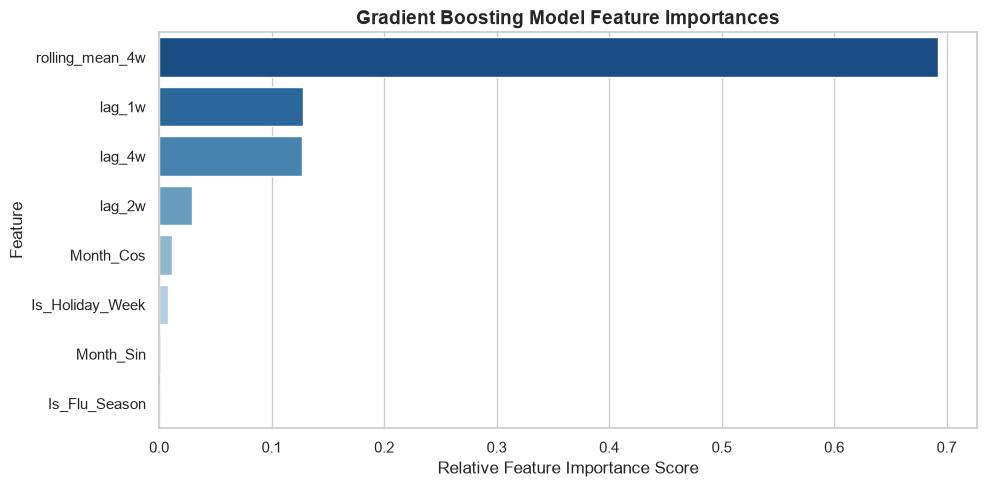

In [43]:
# Extract and Plot Feature Importances
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gbr_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Gradient Boosting Model Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance Score')
plt.tight_layout()
plt.show()

- **`lag_1w`** and **`rolling_mean_4w`** emerge as the dominant predictors, confirming that recent volume and 4-week smoothed momentum provide the primary demand signals.
- **`Is_Flu_Season`** and calendar metrics (`Month_Cos`) provide seasonal adjustments during winter patient surges.

#### 13. Export Trained Model Artifacts to `model/`
This serializes the trained Gradient Boosting model (`weekly_forecasting_model.pkl`) and exports an evaluation metadata JSON file to the `model/` directory.

- Packaging model weights and governance metadata enables automated weekly scoring pipelines in production to load the trained estimator and generate inference within milliseconds without re-running model training.

In [44]:
# Save Model Artifacts to model/
model_dir = os.path.join('..', 'model')
os.makedirs(model_dir, exist_ok=True)

# 1. Save trained Scikit-Learn Model PKL
model_file = os.path.join(model_dir, 'weekly_forecasting_model.pkl')
joblib.dump(gbr_model, model_file)
print(f"Model PKL saved to: {model_file}")

# 2. Save Benchmark Metrics Summary JSON
summary_file = os.path.join(model_dir, 'evaluation_summary.json')
summary_dict = {
    'champion_model': 'GradientBoostingRegressor',
    'evaluation_metrics': {
        'naive_baseline': {'mape': round(naive_mape, 2), 'rmse': round(naive_rmse, 2)},
        'random_forest': {'mape': round(rf_mape, 2), 'rmse': round(rf_rmse, 2)},
        'gradient_boosting': {'mape': round(gbr_mape, 2), 'rmse': round(gbr_rmse, 2)}
    },
    'features': feature_cols
}

with open(summary_file, 'w', encoding='utf-8') as f:
    json.dump(summary_dict, f, indent=2)

print(f"Evaluation Summary JSON saved to: {summary_file}")

Model PKL saved to: ..\model\weekly_forecasting_model.pkl
Evaluation Summary JSON saved to: ..\model\evaluation_summary.json


#### 14. Save Holdout Forecast Results to `data/processed/`
This exports the Q4 holdout predictions table—containing actual demand, naive estimates, and GBR forecasts—to `data/processed/weekly_holdout_predictions.csv`.

- The exported predictions provide the foundational input for **Step 5 (Staffing Guidance)**, where predicted patient counts are translated into operational Doctor and Nurse shift allocations.

In [45]:
# Export Predictions CSV
preds_out = os.path.join('..', 'data', 'processed', 'weekly_holdout_predictions.csv')
test_meta.to_csv(preds_out, index=False)

print("Model Development & Evaluation Complete. Holdout predictions saved to data/processed/weekly_holdout_predictions.csv")

Model Development & Evaluation Complete. Holdout predictions saved to data/processed/weekly_holdout_predictions.csv
